# PayEquity AI — Compensation Gap Intelligence Platform
## Development Roadmap & Learning Curve Plan

This notebook documents the sequential implementation of **PayEquity AI**. The goal of this platform is to determine whether an unexplained gender pay gap exists within the organization after controlling for legitimate business factors (role, seniority, performance, education), and to structure those findings for HR leadership.

---

### 🗺️ Project Implementation Blueprint

#### [PHASE 1] Data Foundations & The Raw Gap (Day 1)
* **Goal:** Establish a clean baseline data layer and calculate unadjusted differences.
* **Steps:**
  * **[1.1] Environment Setup:** Load libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`).
  * **[1.2] Data Loading & Inspection:** Read the Glassdoor Gender Pay Gap CSV and verify dimensions.
  * **[1.3] Demographic Auditing:** Check group sizes (Male vs. Female counts) and verify class balance.
  * **[1.4] Raw Metrics Baseline:** Calculate the mean unadjusted base pay and isolate the **Raw Dollar Gap**.

#### [PHASE 2] Statistical Verification & T-Testing (Day 1–2)
* **Goal:** Prove whether the raw pay gap is a meaningful structural finding or just random variance.
* **Steps:**
  * **[2.1] Variance Tracking:** Isolate salary distributions and check group standard deviations.
  * **[2.2] Two-Sample T-Testing:** Run an independent Welch's T-Test using `scipy.stats`.
  * **[2.3] Probability Assessment:** Evaluate the raw P-Value against the $0.05$ significance threshold.
  * **[2.4] Visual Mapping:** Build a dual-density overlay chart to visually document the salary distribution shift.

#### [PHASE 3] Feature Engineering & Econometric Modeling (Day 2)
* **Goal:** Isolate the **Adjusted Pay Gap** by holding career and educational background variables constant.
* **Steps:**
  * **[3.1] One-Hot Encoding:** Convert categorical strings (`Gender`, `Dept`, `JobTitle`, `Education`) into binary matrices.
  * **[3.2] Baseline Partial Regression:** Fit a simple OLS model controlling strictly for Age and Seniority.
  * **[3.3] Full Control Regression:** Fit a comprehensive `statsmodels.OLS` model across all employee variables.
  * **[3.4] Signficance Flipping Analysis:** Interpret the finalized gender coefficient and its adjusted P-Value.

#### [PHASE 4] Interactive Dashboard Framework (End of Week 1)
* **Goal:** Port backend python metrics into an accessible, non-technical HR user interface.
* **Steps:**
  * **[4.1] UI Architecture:** Initialize a multi-column layout using `streamlit`.
  * **[4.2] KPI Metric Delivery:** Display the Raw vs. Fully-Adjusted gaps side-by-side.
  * **[4.3] Functional Filtering:** Implement interactive sidebar menus for localized department sorting.

---

### 🏷️ Execution Workspace
*Below this cell, all code implementation blocks are labeled to correspond directly with the steps outlined in this blueprint.*


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Glassdoor_Gender_Pay_Gap.csv")

In [3]:
df .shape

(1000, 9)

In [10]:
df .head()

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [11]:
df .head(5)

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [12]:
df .tail(5)

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
995,Marketing Associate,Female,61,1,High School,Administration,1,62644,3270
996,Data Scientist,Male,57,1,Masters,Sales,2,108977,3567
997,Financial Analyst,Male,48,1,High School,Operations,1,92347,2724
998,Financial Analyst,Male,65,2,High School,Administration,1,97376,2225
999,Financial Analyst,Male,60,1,PhD,Sales,2,123108,2244


In [13]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   JobTitle   1000 non-null   object
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   int64 
 3   PerfEval   1000 non-null   int64 
 4   Education  1000 non-null   object
 5   Dept       1000 non-null   object
 6   Seniority  1000 non-null   int64 
 7   BasePay    1000 non-null   int64 
 8   Bonus      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [14]:
df .describe()

,Age,PerfEval,Seniority,BasePay,Bonus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.393000,3.037000,2.971000,94472.653000,6467.161000
std,14.294856,1.423959,1.395029,25337.493272,2004.377365
min,18.000000,1.000000,1.000000,34208.000000,1703.000000
25%,29.000000,2.000000,2.000000,76850.250000,4849.500000
50%,41.000000,3.000000,3.000000,93327.500000,6507.000000
75%,54.250000,4.000000,4.000000,111558.000000,8026.000000
max,65.000000,5.000000,5.000000,179726.000000,11293.000000


In [15]:
df.isnull().sum()

JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

In [49]:
df['Gender'].unique()


array(['Female', 'Male'], dtype=object)

In [50]:
df['Dept'].unique()


array(['Operations', 'Management', 'Administration', 'Sales',
       'Engineering'], dtype=object)

In [51]:
df['Education'].unique()


array(['College', 'PhD', 'Masters', 'High School'], dtype=object)

In [52]:
df['JobTitle'].unique()

array(['Graphic Designer', 'Software Engineer', 'Warehouse Associate',
       'IT', 'Sales Associate', 'Driver', 'Financial Analyst',
       'Marketing Associate', 'Data Scientist', 'Manager'], dtype=object)

In [17]:
df[['Age', 'Seniority', 'PerfEval']].describe()

,Age,Seniority,PerfEval
count,1000.000000,1000.000000,1000.000000
mean,41.393000,2.971000,3.037000
std,14.294856,1.395029,1.423959
min,18.000000,1.000000,1.000000
25%,29.000000,2.000000,2.000000
50%,41.000000,3.000000,3.000000
75%,54.250000,4.000000,4.000000
max,65.000000,5.000000,5.000000


In [20]:
df['Gender'].value_counts()

Gender
Male      532
Female    468
Name: count, dtype: int64

In [21]:
gender_avg = df.groupby('Gender')['BasePay'].mean()

male_avg = gender_avg['Male']
female_avg = gender_avg['Female']

raw_gap = male_avg - female_avg
print(f"Raw pay gap: ${raw_gap:,.2f}")

Raw pay gap: $8,514.73


Calculate std dev for each group
- Compare them — are they close or very different?
- Based on that, decide: similar variance → regular t-test; different variance → Welch's t-test
- Run the t-test with that decision already made

In [33]:
print(f"Male std dev: ${male_pay.std():,.2f}")
print(f"Female std dev: ${female_pay.std():,.2f}")

Male std dev: $25,517.52
Female std dev: $24,378.28


EDA and aggregation of data to understand the gender pay gap in the dataset. Code calculates the average base pay for male and female employees.
    Next step: is that gap statistically significant, or could it just be random noise ?

Using - T test - Scipy.stats

I split Basepay - seperate groups - for male & Female
Run T- Test comparing the 2 groups 

In [31]:
from scipy import stats
male_pay = df[df['Gender'] == 'Male']['BasePay']
female_pay = df[df['Gender'] == 'Female']['BasePay']

t_stat, p_value = stats.ttest_ind(male_pay, female_pay, equal_var=False)


print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")

T-statistic: 5.3918
P-value: 8.72e-08


p-value: 8.72e-08 = basically 0.0000000872 — an incredibly tiny chance. So the gap is almost certainly not just random luck.


if p < 0.05 → "real" difference. If p > 0.05 → could just be luck. 

I use Welch's T-Test doesnot make that assumption
so, it adjust for both group. 

Found :: Male salary spread ($25,517) and Female salary spread ($24,378) aren't identical.

Welch's test correctly accounts for that difference instead of pretending it doesn't exist. That's why it's the safer, more honest choice, Mathematically proved.

now  raw gap + significance confirmed.

Since the standard deviations differ between groups, a Welch's t-test was used, confirming the $8,514.73 raw gap is statistically significant (p = 8.72e-08).

Nxt Step : Regression -

T test will not tell us the Reason.
May be really are paid unfairly ?
May be men in dataset just happen to have more seniortiy or Work in higher -paying departments?

If I compare a man and a woman who have the exact same seniority, same age, same department, same job title — is there still a pay difference?


for example

 compare two people:

A 25-year-old junior employee
A 45-year-old senior manager

Of course the manager earns more — that's not gender bias, that's seniority. If your comparison group happens to have more men in senior roles, the raw gap will look huge, even if pay is perfectly fair within each role. Regression removes that distortion.

which can be explained by many factors?
in Real time they get scrutinized when the gap persists after controlling for legitimate business factors.




Regression :  Lets try  Age and Senirotiy and check the gap. 

Let me try with foundation step.

Regession model - need math cal with numbers 
so i want new column

dummies 
Male - True - 1
Female - False - 0


In [34]:
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df_encoded.head()

,JobTitle,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus,Gender_Male
0,Graphic Designer,18,5,College,Operations,2,42363,9938,False
1,Software Engineer,21,5,College,Management,5,108476,11128,True
2,Warehouse Associate,19,4,PhD,Administration,5,90208,9268,False
3,Software Engineer,20,5,Masters,Sales,4,108080,10154,True
4,Graphic Designer,26,5,Masters,Engineering,5,99464,9319,True


In [38]:
X = df_encoded[['Age', 'Seniority', 'Gender_Male']].astype(float)
X = sm.add_constant(X)
y = df_encoded['BasePay']

model = sm.OLS(y, X).fit()
print(model.params)
print(model.pvalues)

const          18008.107579
Age             1027.539481
Seniority       9610.164379
Gender_Male    10112.416009
dtype: float64
const           7.333297e-20
Age            8.380188e-142
Seniority      6.890381e-124
Gender_Male     7.847100e-24
dtype: float64


both showing the same four things: const, Age, Seniority, Gender_Male.

First list = coefficients (dollar impact on pay)
Second list = p-values (is that impact statistically real?)

The surprising part — compare to your raw gap
Raw gap (no adjustment): $8,514.73
Adjusted for Age + Seniority only: $10,112.42

"When comparing a man and a woman of the exact same age and seniority, the man is predicted to earn $10,112 more — and this is highly statistically significant

In [39]:
df_fully_encoded = pd.get_dummies(df, columns=['Gender', 'Dept', 'JobTitle', 'Education'], drop_first=True)
df_fully_encoded.head()

,Age,PerfEval,Seniority,BasePay,Bonus,Gender_Male,Dept_Engineering,Dept_Management,Dept_Operations,Dept_Sales,...,JobTitle_Graphic Designer,JobTitle_IT,JobTitle_Manager,JobTitle_Marketing Associate,JobTitle_Sales Associate,JobTitle_Software Engineer,JobTitle_Warehouse Associate,Education_High School,Education_Masters,Education_PhD
0,18,5,2,42363,9938,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,21,5,5,108476,11128,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,19,4,5,90208,9268,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,20,5,4,108080,10154,True,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
4,26,5,5,99464,9319,True,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [40]:
predictor_cols = [col for col in df_fully_encoded.columns if col not in ['BasePay', 'Bonus']]

X_all = df_fully_encoded[predictor_cols].astype(float)
X_all = sm.add_constant(X_all)
y = df_fully_encoded['BasePay']

final_model = sm.OLS(y, X_all).fit()

print(final_model.params['Gender_Male'])
print(final_model.pvalues['Gender_Male'])

777.7932739561393
0.27652409809542233


predictor_cols — grabs every column except BasePay and Bonus 

astype(float) — same fix as before, avoids the boolean/object error you hit earlier

We're only printing Gender_Male at the end, since that's the number  actually care about — the fully-adjusted pay gap

What this means — the full story now complete
Stage	            Gap	            Significant?

Raw (no adjustment)  	$8,514.73	      Yes
+ Age & Seniority only	$10,112.42	      Yes
+ Everything 
(Dept, Job Title, 
Education too)	         $777.79	 No (p = 0.28)

why did the gap get bigger after adding Age + Seniority?

the women's slight seniority/age advantage was quietly offsetting some of the pay difference

-Once  control for age and seniority so masking effect goes away — and the "true" underlying gap, driven only by gender, becomes visible: $10,112


what does it mean that the gap disappeared after adding Dept + Job Title?

Once  also compare people in the same department and same job title, the gap almost gone.

means: men and women doing the same job are paid similarly.

earlier big gap wasn't really about unequal pay for equal work — it was because men are more concentrated in certain departments/roles

(probably higher-paying ones, like Engineering), and women are more concentrated in others.




The raw pay gap of $8,514.73 initially got larger ($10,112) when we controlled only for age and seniority, because women in this dataset have slightly favorable age/seniority profiles that were masking the true gap. But once we also controlled for department and job title, the gap shrank to just $777.79 and became statistically insignificant (p = 0.28), meaning the original gap was driven by uneven representation across roles and departments, not unequal pay for the same job

## Summary of Findings

| Stage | Estimated Gap | p-value | Significant? |
|---|---|---|---|
| Raw gap | $8,514.73 | 8.72e-08 | Yes |
| Adjusted for Age + Seniority | $10,112.42 | 7.85e-24 | Yes |
| Fully adjusted (+ Dept, Job Title, Education) | $777.79 | 0.28 | No |

**Conclusion:** The raw pay gap is not explained by unequal pay for equal work — it's explained by uneven representation of men and women across departments and job titles. This suggests a representation/hiring issue rather than a compensation policy issue.

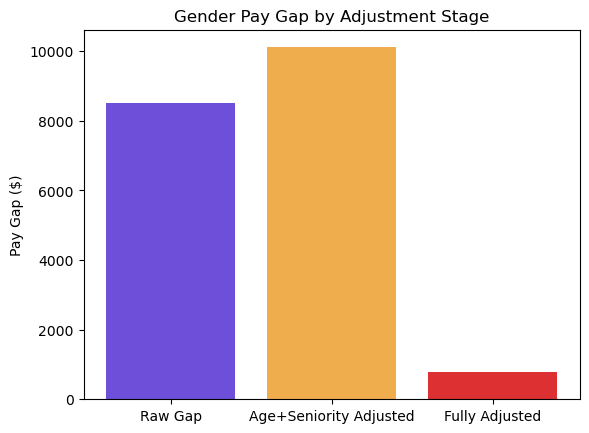

In [47]:

#Bar chart comparing raw vs. adjusted gap
import matplotlib.pyplot as plt

stages = ['Raw Gap', 'Age+Seniority Adjusted', 'Fully Adjusted']
values = [8514.73, 10112.42, 777.79]

plt.bar(stages, values, color=["#6d4fd9", '#f0ad4e', "#dc3033"])
plt.ylabel('Pay Gap ($)')
plt.title('Gender Pay Gap by Adjustment Stage')
plt.show()

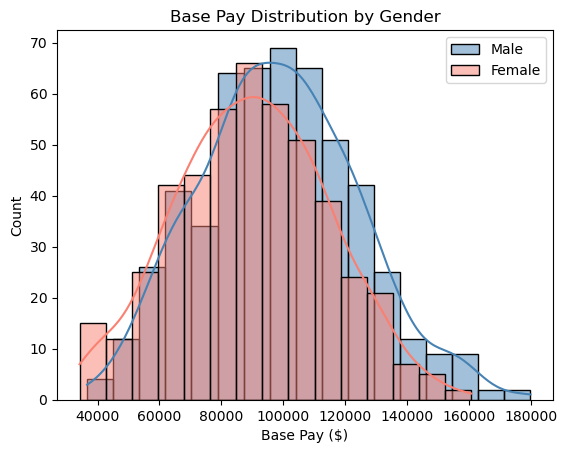

In [44]:

#Distribution overlay — pay spread by gender
import seaborn as sns

sns.histplot(male_pay, color='steelblue', label='Male', kde=True, alpha=0.5)
sns.histplot(female_pay, color='salmon', label='Female', kde=True, alpha=0.5)
plt.legend()
plt.title('Base Pay Distribution by Gender')
plt.xlabel('Base Pay ($)')
plt.show()

connect with PBI 



In [4]:
departments = df['Dept'].unique()

results = []

for dept in departments:
    dept_df = df[df['Dept'] == dept]
    # your regression code goes here, using dept_df instead of df
    # store the results in a dictionary and append to results list

In [5]:
departments = df['Dept'].unique()

for dept in departments:
    dept_df = df[df['Dept'] == dept]
    print(f"{dept}: {len(dept_df)} employees")

Operations: 210 employees
Management: 198 employees
Administration: 193 employees
Sales: 207 employees
Engineering: 192 employees


In [6]:
departments = df['Dept'].unique()
results = []

for dept in departments:
    dept_df = df[df['Dept'] == dept]
    
    male_pay_d = dept_df[dept_df['Gender'] == 'Male']['BasePay']
    female_pay_d = dept_df[dept_df['Gender'] == 'Female']['BasePay']
    
    raw_gap_d = male_pay_d.mean() - female_pay_d.mean()
    
    print(f"{dept}: Raw gap = ${raw_gap_d:,.2f} ({len(male_pay_d)} men, {len(female_pay_d)} women)")

Operations: Raw gap = $6,662.28 (114 men, 96 women)
Management: Raw gap = $6,803.29 (111 men, 87 women)
Administration: Raw gap = $9,098.87 (98 men, 95 women)
Sales: Raw gap = $9,482.40 (106 men, 101 women)
Engineering: Raw gap = $10,658.04 (103 men, 89 women)


In [7]:
import statsmodels.api as sm

departments = df['Dept'].unique()
results = []

for dept in departments:
    dept_df = df[df['Dept'] == dept]
    
    male_pay_d = dept_df[dept_df['Gender'] == 'Male']['BasePay']
    female_pay_d = dept_df[dept_df['Gender'] == 'Female']['BasePay']
    raw_gap_d = male_pay_d.mean() - female_pay_d.mean()
    
    # One-hot encode within this department's subset
    dept_encoded = pd.get_dummies(dept_df, columns=['Gender', 'JobTitle', 'Education'], drop_first=True)
    
    predictor_cols = [col for col in dept_encoded.columns if col not in ['BasePay', 'Bonus', 'Dept']]
    X = dept_encoded[predictor_cols].astype(float)
    X = sm.add_constant(X)
    y = dept_encoded['BasePay']
    
    model = sm.OLS(y, X).fit()
    
    adjusted_gap_d = model.params.get('Gender_Male', None)
    p_value_d = model.pvalues.get('Gender_Male', None)
    
    print(f"{dept}: Raw=${raw_gap_d:,.2f} | Adjusted=${adjusted_gap_d:,.2f} | p={p_value_d:.4f}")
    
    results.append({
        'Department': dept,
        'Raw_Gap': round(raw_gap_d, 2),
        'Adjusted_Gap': round(adjusted_gap_d, 2),
        'P_Value': round(p_value_d, 4)
    })

Operations: Raw=$6,662.28 | Adjusted=$-120.71 | p=0.9388
Management: Raw=$6,803.29 | Adjusted=$1,759.24 | p=0.2749
Administration: Raw=$9,098.87 | Adjusted=$-905.68 | p=0.6138
Sales: Raw=$9,482.40 | Adjusted=$1,946.57 | p=0.2707
Engineering: Raw=$10,658.04 | Adjusted=$638.12 | p=0.6698


In [8]:
results_df = pd.DataFrame(results)
results_df

,Department,Raw_Gap,Adjusted_Gap,P_Value
0,Operations,6662.28,-120.71,0.9388
1,Management,6803.29,1759.24,0.2749
2,Administration,9098.87,-905.68,0.6138
3,Sales,9482.40,1946.57,0.2707
4,Engineering,10658.04,638.12,0.6698


In [9]:
# Add the overall (all-department) result as its own row
all_row = {
    'Department': 'All Corporate',
    'Raw_Gap': 8514.73,
    'Adjusted_Gap': 777.79,
    'P_Value': 0.2765
}

results_df = pd.concat([pd.DataFrame([all_row]), results_df], ignore_index=True)

# Add traffic-light status based on p-value
def get_status(p):
    if p < 0.05:
        return '🔴 Red'
    elif p < 0.10:
        return '🟡 Amber'
    else:
        return '🟢 Green'

results_df['Status'] = results_df['P_Value'].apply(get_status)

results_df

,Department,Raw_Gap,Adjusted_Gap,P_Value,Status
0,All Corporate,8514.73,777.79,0.2765,🟢 Green
1,Operations,6662.28,-120.71,0.9388,🟢 Green
2,Management,6803.29,1759.24,0.2749,🟢 Green
3,Administration,9098.87,-905.68,0.6138,🟢 Green
4,Sales,9482.40,1946.57,0.2707,🟢 Green
5,Engineering,10658.04,638.12,0.6698,🟢 Green


In [10]:
results_df.to_csv('../data/payequity_results.csv', index=False)
print("Saved to data/payequity_results.csv")

Saved to data/payequity_results.csv
